## 1. Loading the Dataset
Importing required libraries and loading the Titanic dataset to begin analysis.

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Questions to Explore
1. What was the overall survival rate on the Titanic?
2. Did gender affect survival chances?
3. Did passenger class affect survival chances?
4. Does the combination of class and sex show a stronger survival pattern?
5. What was the age distribution of passengers, and are there any outliers in age or fare?

## 2. Exploring Data Structure
Checking the size of the dataset, column names, and data types to understand what we're working with.

In [3]:
df.shape

(891, 15)

In [4]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [5]:
print(df.dtypes)

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


## 3. Checking for Missing Values
Identifying which columns have missing data and how severe the issue is.

In [6]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 4. Checking for Duplicate Rows
Detecting potential data quality issues by checking for duplicate entries.

In [7]:
df.duplicated().sum()

np.int64(107)

## 5. Statistical Summary
Generating summary statistics (mean, min, max, etc.) for numeric columns to understand the data's distribution.

In [8]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 6. Key Question: What Was the Overall Survival Rate?

In [9]:
df['survived'].mean() * 100

np.float64(38.38383838383838)

## 7. Key Question: Did Sex Affect Survival?
Testing the hypothesis that gender influenced survival chances.

In [10]:
df.groupby('sex')['survived'].mean() * 100

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

## 8. Key Question: Did Passenger Class Affect Survival?
Testing the hypothesis that wealthier passengers (1st class) had better survival odds.

In [11]:
df.groupby('pclass')['survived'].mean() * 100

pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64

## 9. Combined Analysis: Class and Sex Together
Looking at survival rates across both class and sex simultaneously to find the strongest pattern.

In [12]:
df.groupby(['pclass', 'sex'])['survived'].mean() * 100

pclass  sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.544669
Name: survived, dtype: float64

## 10. Visualization: Survival Count

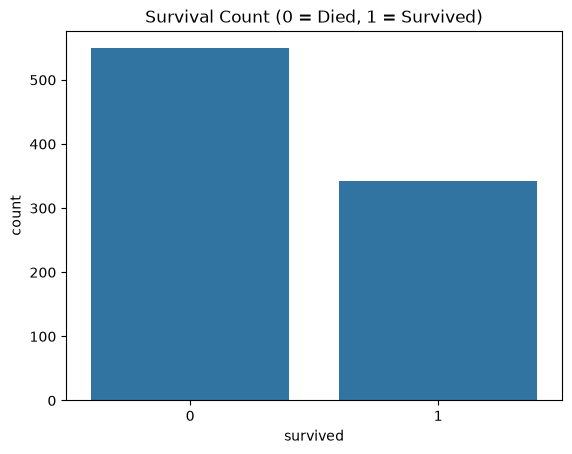

In [13]:
sns.countplot(data=df, x='survived')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.show()

## 11. Visualization: Survival Rate by Sex

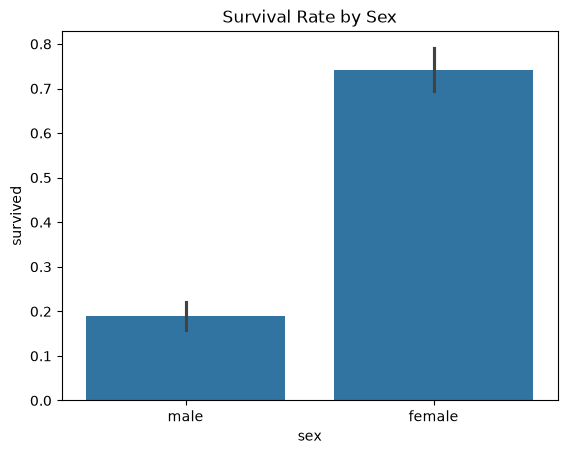

In [14]:
sns.barplot(data=df, x='sex', y='survived')
plt.title('Survival Rate by Sex')
plt.show()

## 12. Visualization: Survival Rate by Class

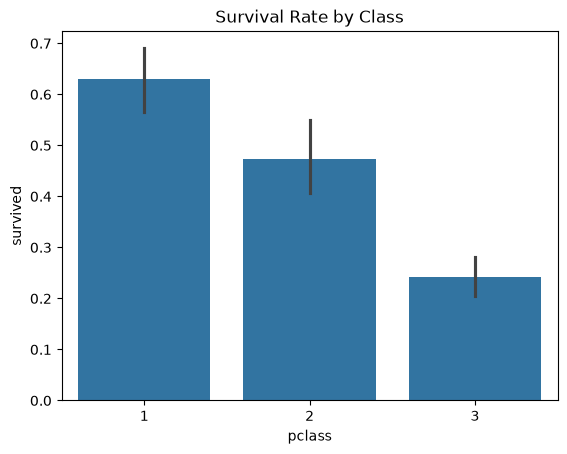

In [15]:
sns.barplot(data=df, x='pclass', y='survived')
plt.title('Survival Rate by Class')
plt.show()

## 13. Visualization: Age Distribution

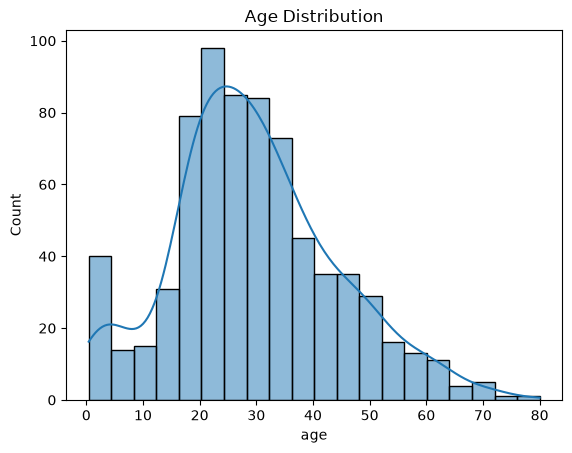

In [16]:
sns.histplot(df['age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()

## 14. Checking for Outliers
Detecting potential anomalies in age and fare that could affect analysis.

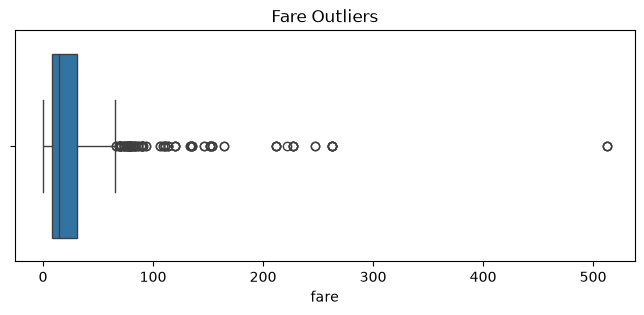

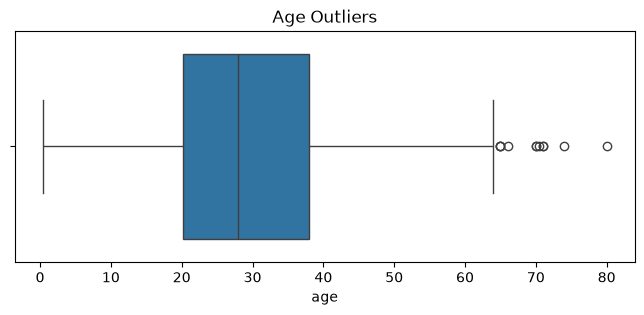

In [17]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['fare'])
plt.title('Fare Outliers')
plt.show()

plt.figure(figsize=(8,3))
sns.boxplot(x=df['age'].dropna())
plt.title('Age Outliers')
plt.show()

## 14. Visualization: Correlation Heatmap
Exploring relationships between numeric variables.

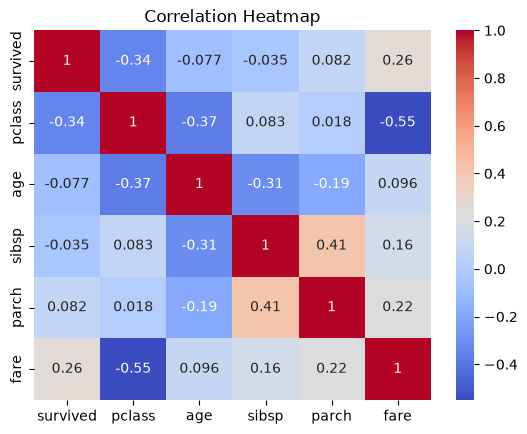

In [18]:
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Key Findings
1. The overall survival rate was approximately 38%.
2. Females had a significantly higher survival rate than males.
3. First-class passengers had a much higher survival rate than second or third class.
4. First-class females had the highest survival rate of all groups combined.
5. Fare shows several high-value outliers, suggesting a small number of passengers paid disproportionately more.